In [14]:
#importo las librerias necesarias
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Te pongo la ruta en relativa para que puedas abrir el dataset, para eso añado los ".." al principio de la ruta

In [4]:
df = pd.read_csv("../data/framingham.csv")

In [5]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Hago una visión general

In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [7]:
df.isnull().sum()


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64

reviso los valores nulos para detectar posibles problemas antes del análisis
si existen pocos valores nulos se pueden eliminar 


In [9]:
df.duplicated().sum()

np.int64(0)

Elimino los duplicados

In [10]:
df = df.drop_duplicates()

In [ ]:
#me he ayudado de la ia
#imputación simple
df["glucose"].fillna(df["glucose"].median(), inplace=True)
df["BMI"].fillna(df["BMI"].median(), inplace=True)
df["totChol"].fillna(df["totChol"].median(), inplace=True)

# categóricas
df["education"].fillna(df["education"].mode()[0], inplace=True)
df["BPMeds"].fillna(0, inplace=True)
df["cigsPerDay"].fillna(0, inplace=True)

C:\Users\Javier\AppData\Local\Temp\ipykernel_36916\972538913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["glucose"].fillna(df["glucose"].median(), inplace=True)
C:\Users\Javier\AppData\Local\Temp\ipykernel_36916\972538913.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

Aunque me haya hayudado de la ia, se que para las variables númericas se les asocia la media o mediana, para las categóricas la moda y para las variables con un significado lógico con valores coherentes (ejemplo:0). Ya que no todas las variables se tratan igual

Hago el análisis univariante 

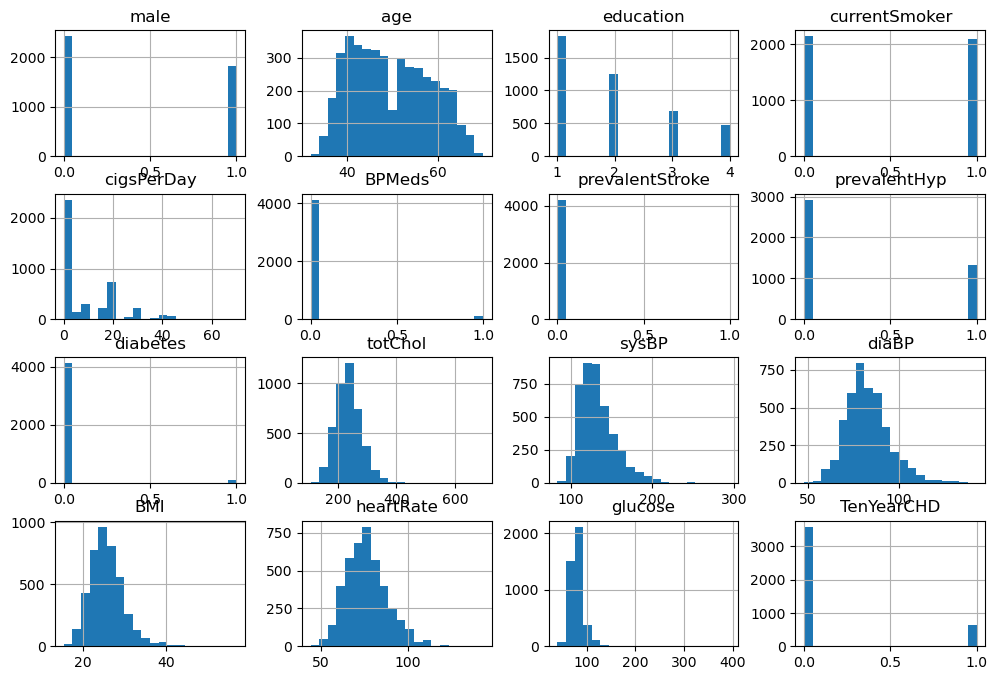

In [12]:
df.hist(bins=20, figsize=(12,8))
plt.show()

df.hist le dice a la librería pandas hazme un histograma de todas las variables numéricas del dataset como dice si nombre "hist" de "histograma"
divido los parámetros en 20 bloques y figsize se refiere al tamaño de la figura(12 ancho, 8 largo)

Como la gráfica no esta del todo clara hago un nuevo analisis univariante basandome como ejemplo en el EDA de hotel_bookings, quitando antes las binarias (0/1)

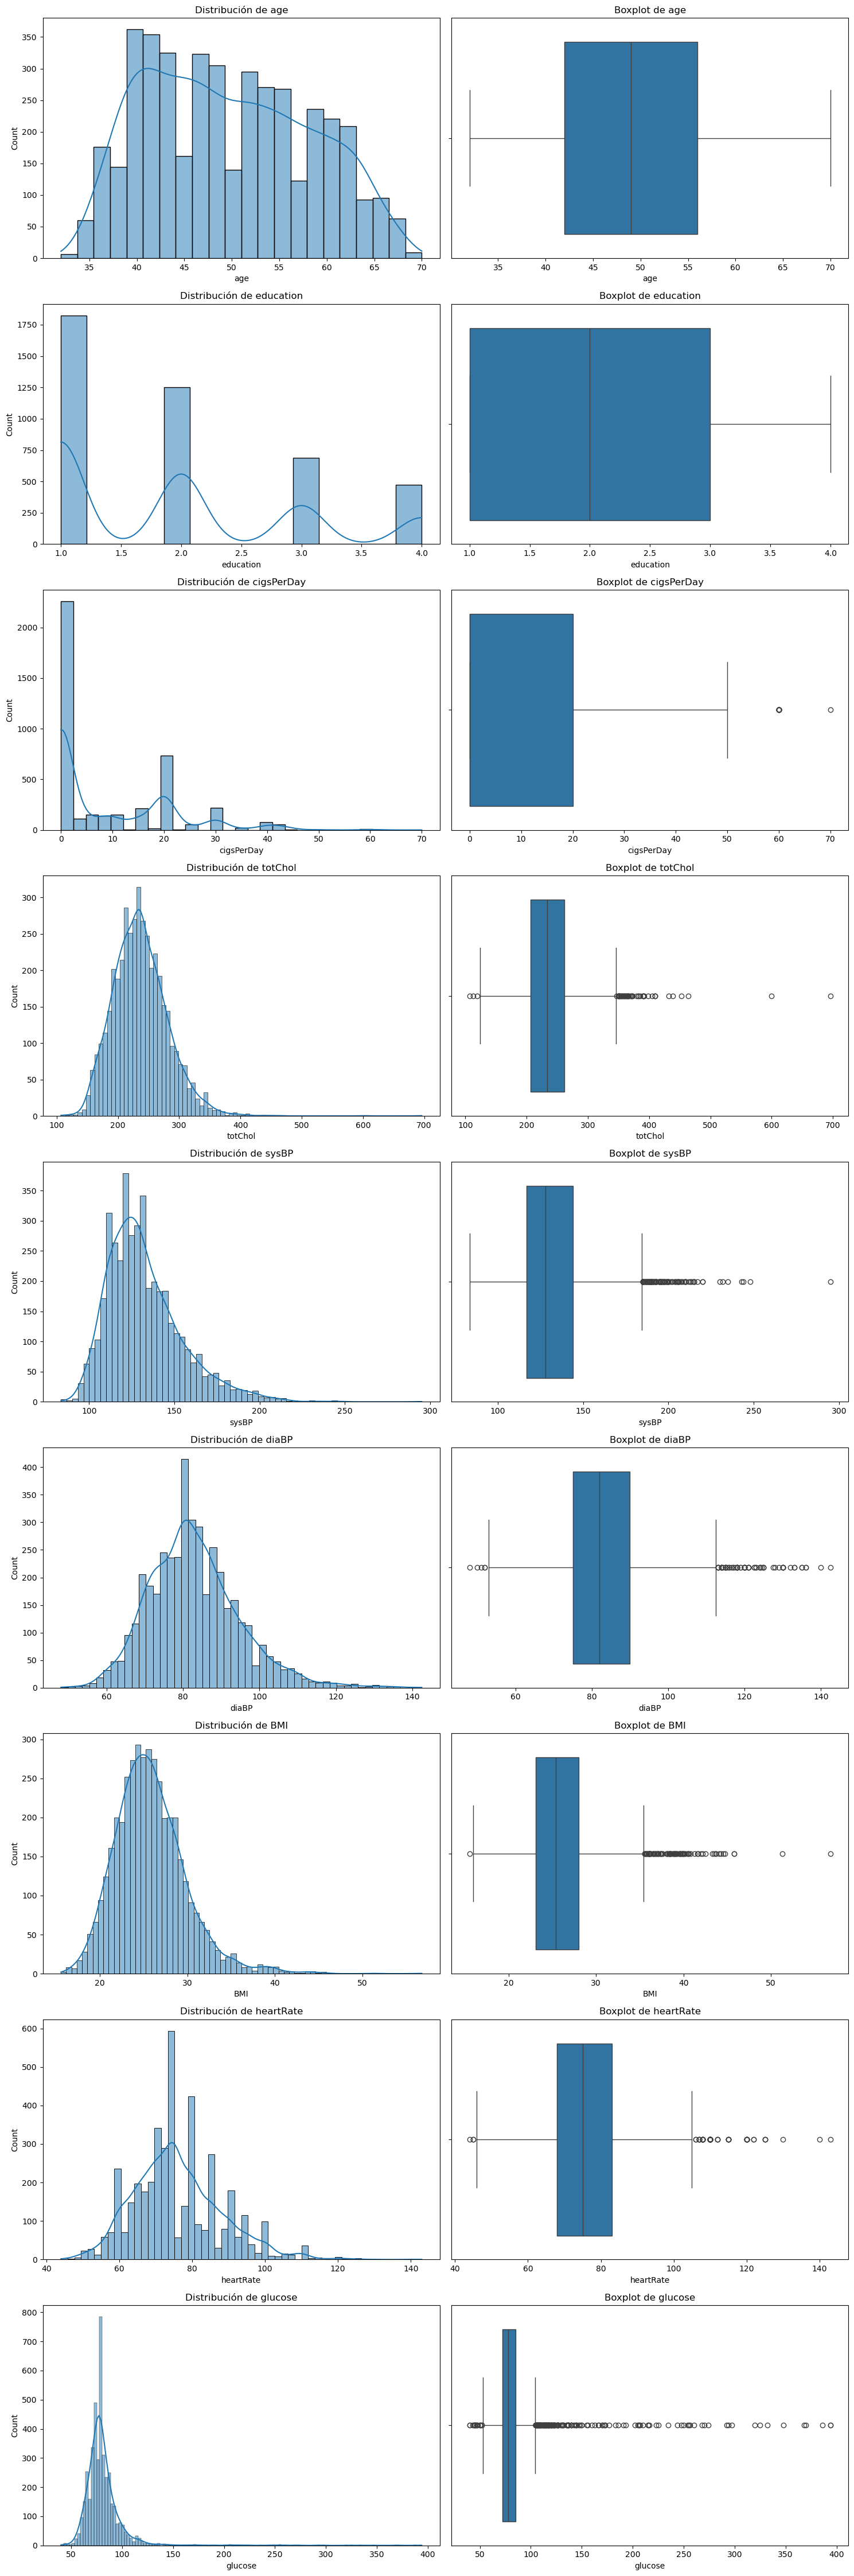

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Aqui es donde quito las  variables binarias
numeric_cols = [col for col in numeric_cols if df[col].nunique() > 2]

fig, axes = plt.subplots(
    nrows=len(numeric_cols), 
    ncols=2, 
    figsize=(15, 5 * len(numeric_cols))
)

for i, column in enumerate(numeric_cols):
    
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribución de {column}')
    
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

Hago el análisis bivariante
edad vs riesgo

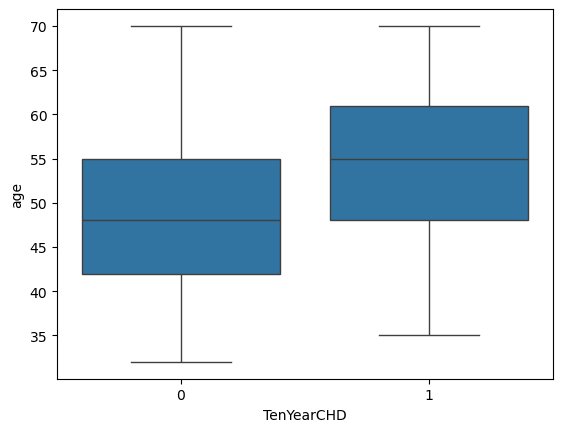

In [16]:
sns.boxplot(x="TenYearCHD", y="age", data=df)
plt.show()

Aquí podemos ver que los pacientes con mayor edad muestran mayor probabilidad de desarrollar  enfermedad

Presión arterial

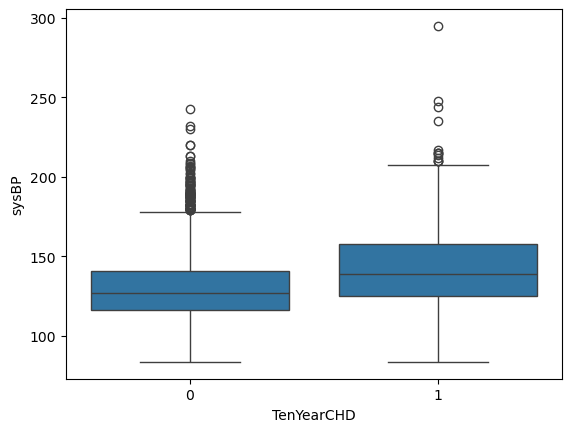

In [19]:
sns.boxplot(x="TenYearCHD", y="sysBP", data=df)
plt.show()

Colesterol

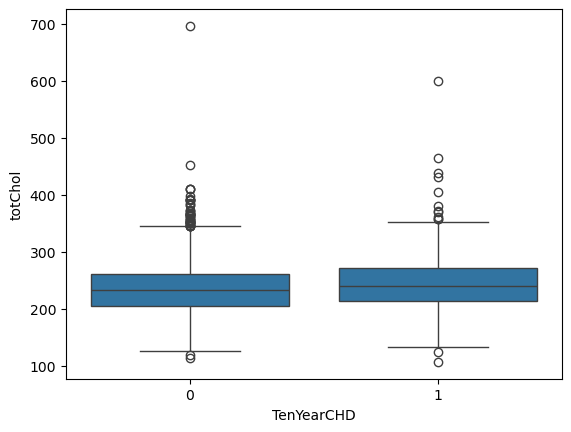

In [20]:
sns.boxplot(x="TenYearCHD", y="totChol", data=df)
plt.show()

Fumar

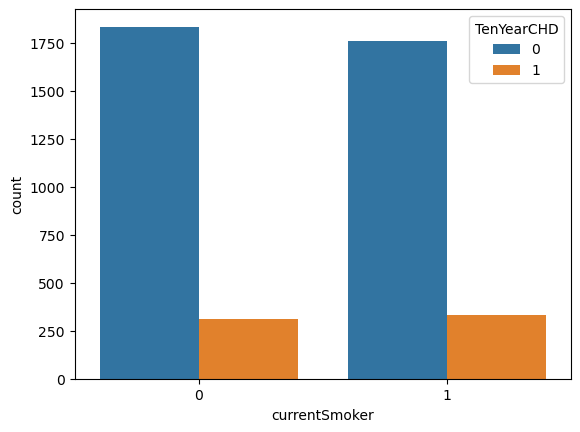

In [21]:
sns.countplot(x="currentSmoker", hue="TenYearCHD", data=df)
plt.show()

Aqui voy a hacer un análisi bivariado basandome en el EDA de hotel bookings pero con mi dataset cambiando los datos

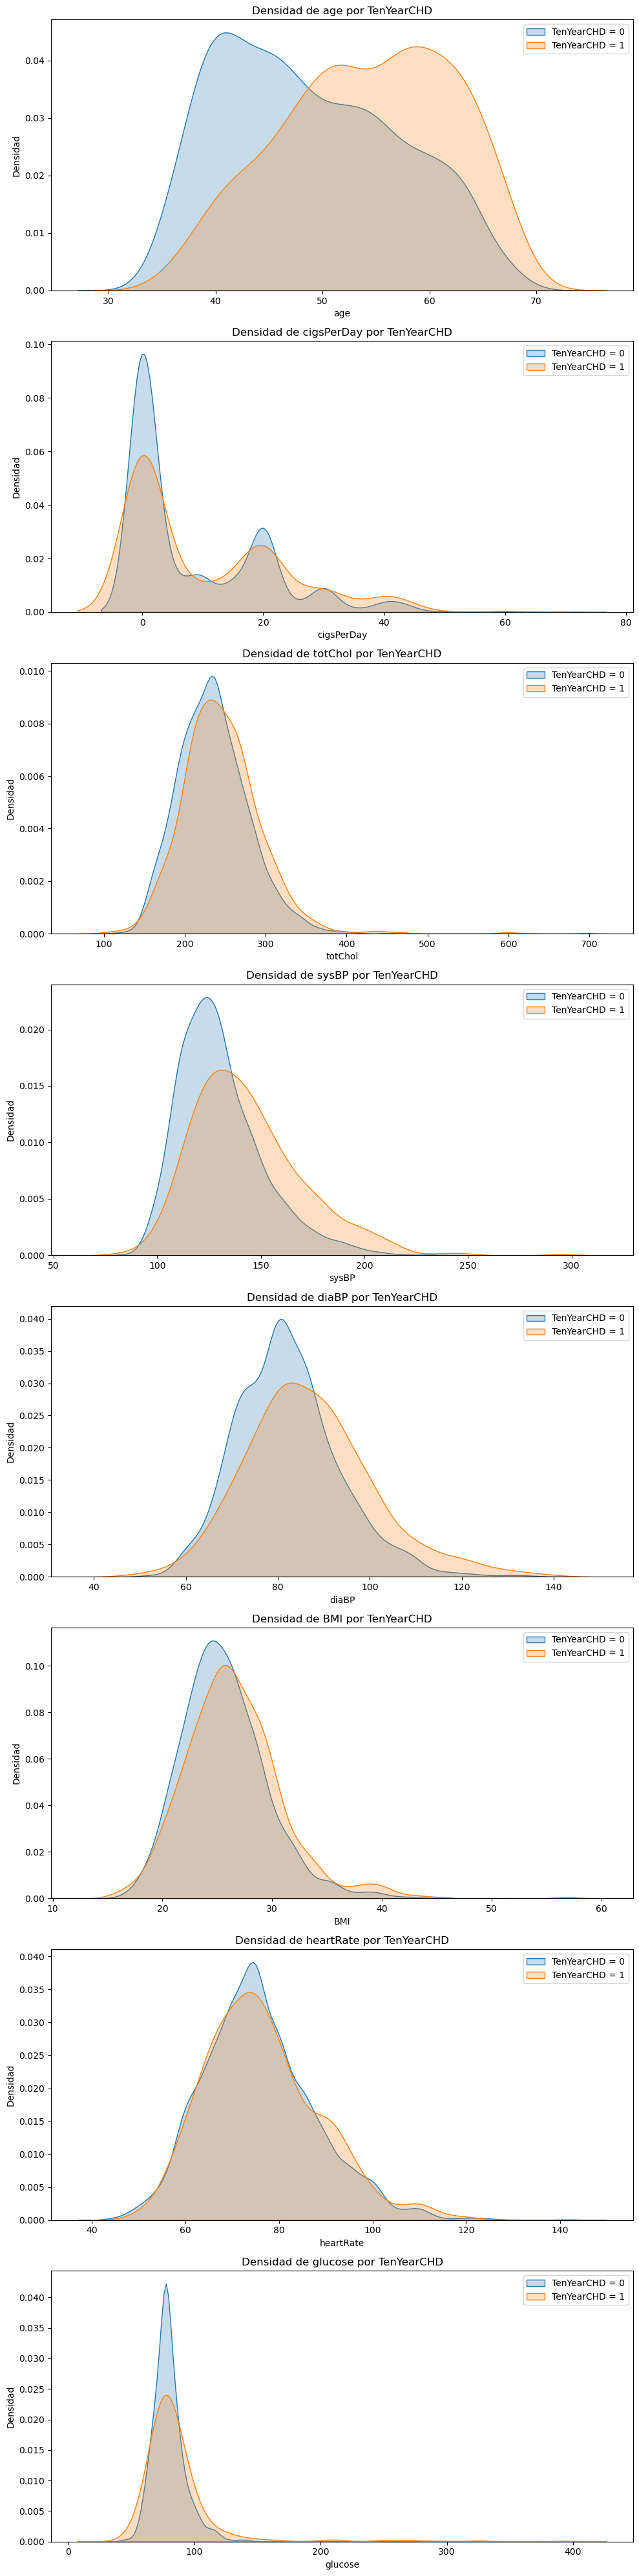

In [24]:
target = 'TenYearCHD'

numeric_cols = [
    'age',
    'cigsPerDay',
    'totChol',
    'sysBP',
    'diaBP',
    'BMI',
    'heartRate',
    'glucose'
]

fig, axs = plt.subplots(
    nrows=len(numeric_cols),
    ncols=1,
    figsize=(10, 5 * len(numeric_cols))
)

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=df[df[target] == 0],
        x=col,
        ax=axs[i],
        label=f'{target} = 0',
        fill=True
    )
    
    sns.kdeplot(
        data=df[df[target] == 1],
        x=col,
        ax=axs[i],
        label=f'{target} = 1',
        fill=True
    )
    
    axs[i].set_title(f'Densidad de {col} por {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Densidad')
    axs[i].legend()

plt.tight_layout()
plt.show()

Hago un análisis descriptivo también tomando como ejemplo el EDA de hotel_bookings  de variables numéricas y muestro estadísticas como "numero de valores", "media", "desviacion estandar", "minimo", "cuartiles", "percentiles bajos", "máximo"

In [25]:
df.describe(include=[np.number], percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False).style.background_gradient(cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
totChol,4240.000000,236.667689,44.328480,107.000000,206.000000,234.000000,262.000000,292.000000,312.000000,353.610000,696.000000
sysBP,4240.000000,132.354599,22.033300,83.500000,117.000000,128.000000,144.000000,162.000000,175.000000,200.000000,295.000000
diaBP,4240.000000,82.897759,11.910394,48.000000,75.000000,82.000000,90.000000,98.000000,104.525000,118.000000,142.500000
glucose,4240.000000,81.600943,22.860340,40.000000,72.000000,78.000000,85.000000,97.000000,107.000000,170.000000,394.000000
heartRate,4239.000000,75.878981,12.025348,44.000000,68.000000,75.000000,83.000000,92.000000,98.000000,110.000000,143.000000
age,4240.000000,49.580189,8.572942,32.000000,42.000000,49.000000,56.000000,62.000000,64.000000,67.000000,70.000000
BMI,4240.000000,25.799005,4.070775,15.540000,23.077500,25.400000,28.032500,30.761000,32.770500,38.952200,56.800000
education,4240.000000,1.955189,1.018522,1.000000,1.000000,2.000000,3.000000,4.000000,4.000000,4.000000,4.000000
male,4240.000000,0.429245,0.495027,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
currentSmoker,4240.000000,0.494104,0.500024,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Esto es para  Para aquellos valores que tienen el 90% de los valores en un solo valor, vemos la distribución de valores únicos y decidimos si son susceptibles de ser eliminados
Y he obtenido ayuda de la IA

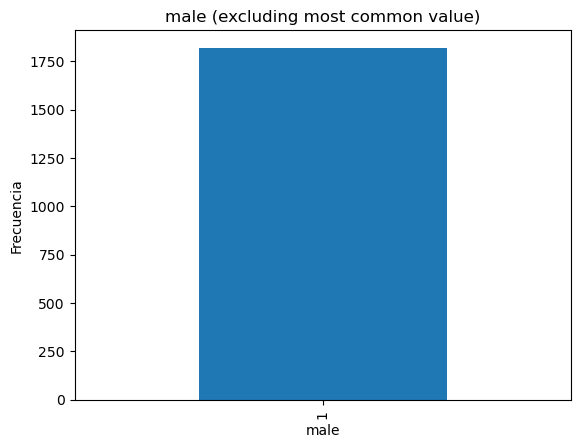

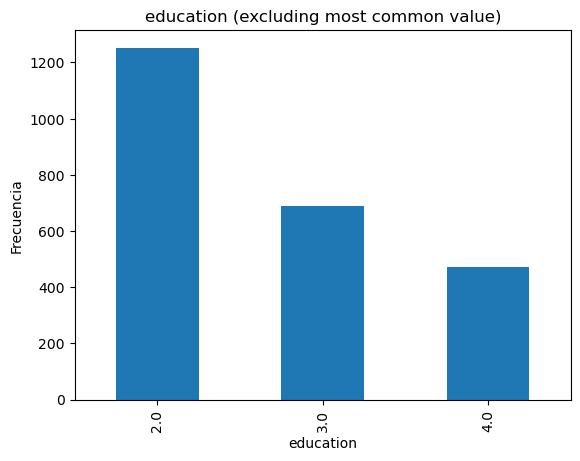

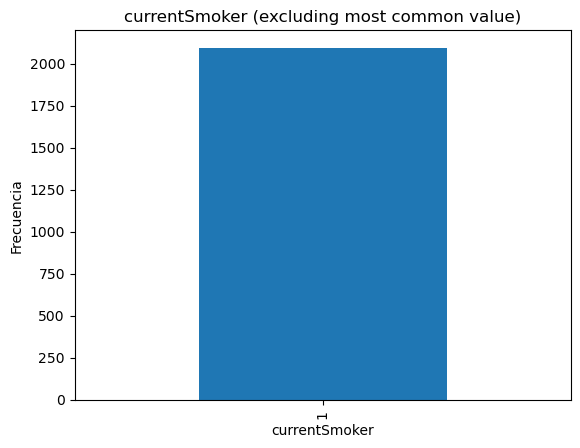

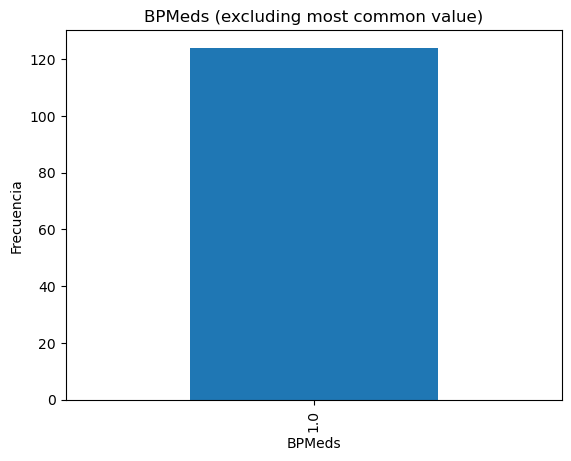

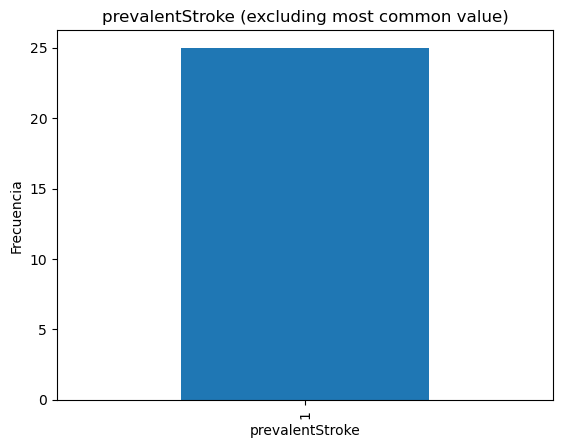

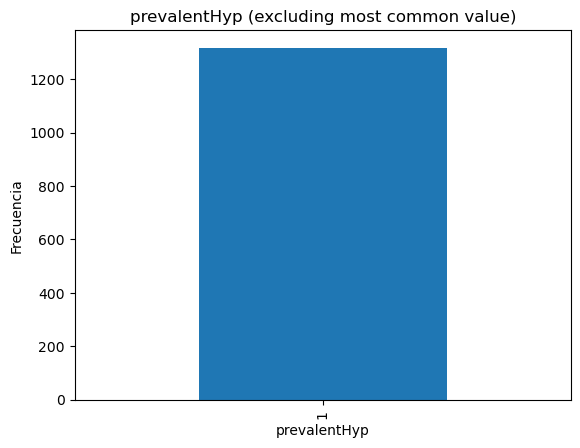

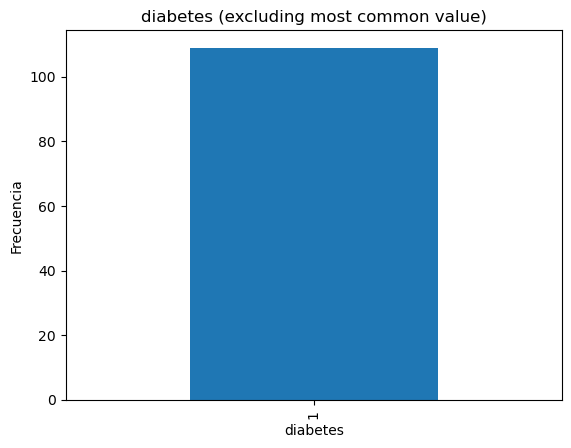

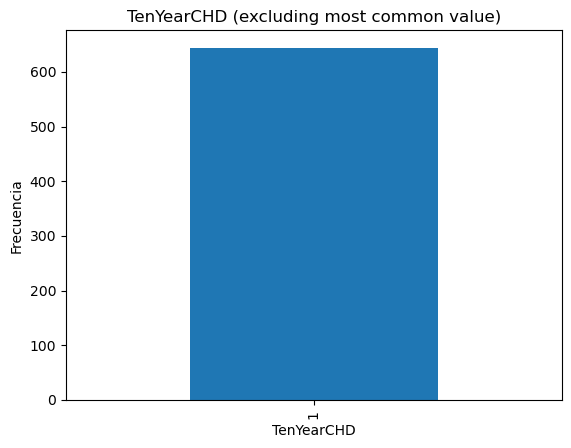

In [27]:
numeric_cols_low_cardinality = [
    'male',
    'education',
    'currentSmoker',
    'BPMeds',
    'prevalentStroke',
    'prevalentHyp',
    'diabetes',
    'TenYearCHD'
]

# Para variables con baja cardinalidad, excluimos el valor más frecuente
# y observamos la distribución del resto de valores

for col in df[numeric_cols_low_cardinality].columns:
    most_common_value = df[col].value_counts().idxmax()
    filtered_data = df[col][df[col] != most_common_value]
    
    plt.figure()
    filtered_data.value_counts().plot(kind='bar')
    plt.title(f'{col} (excluding most common value)')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

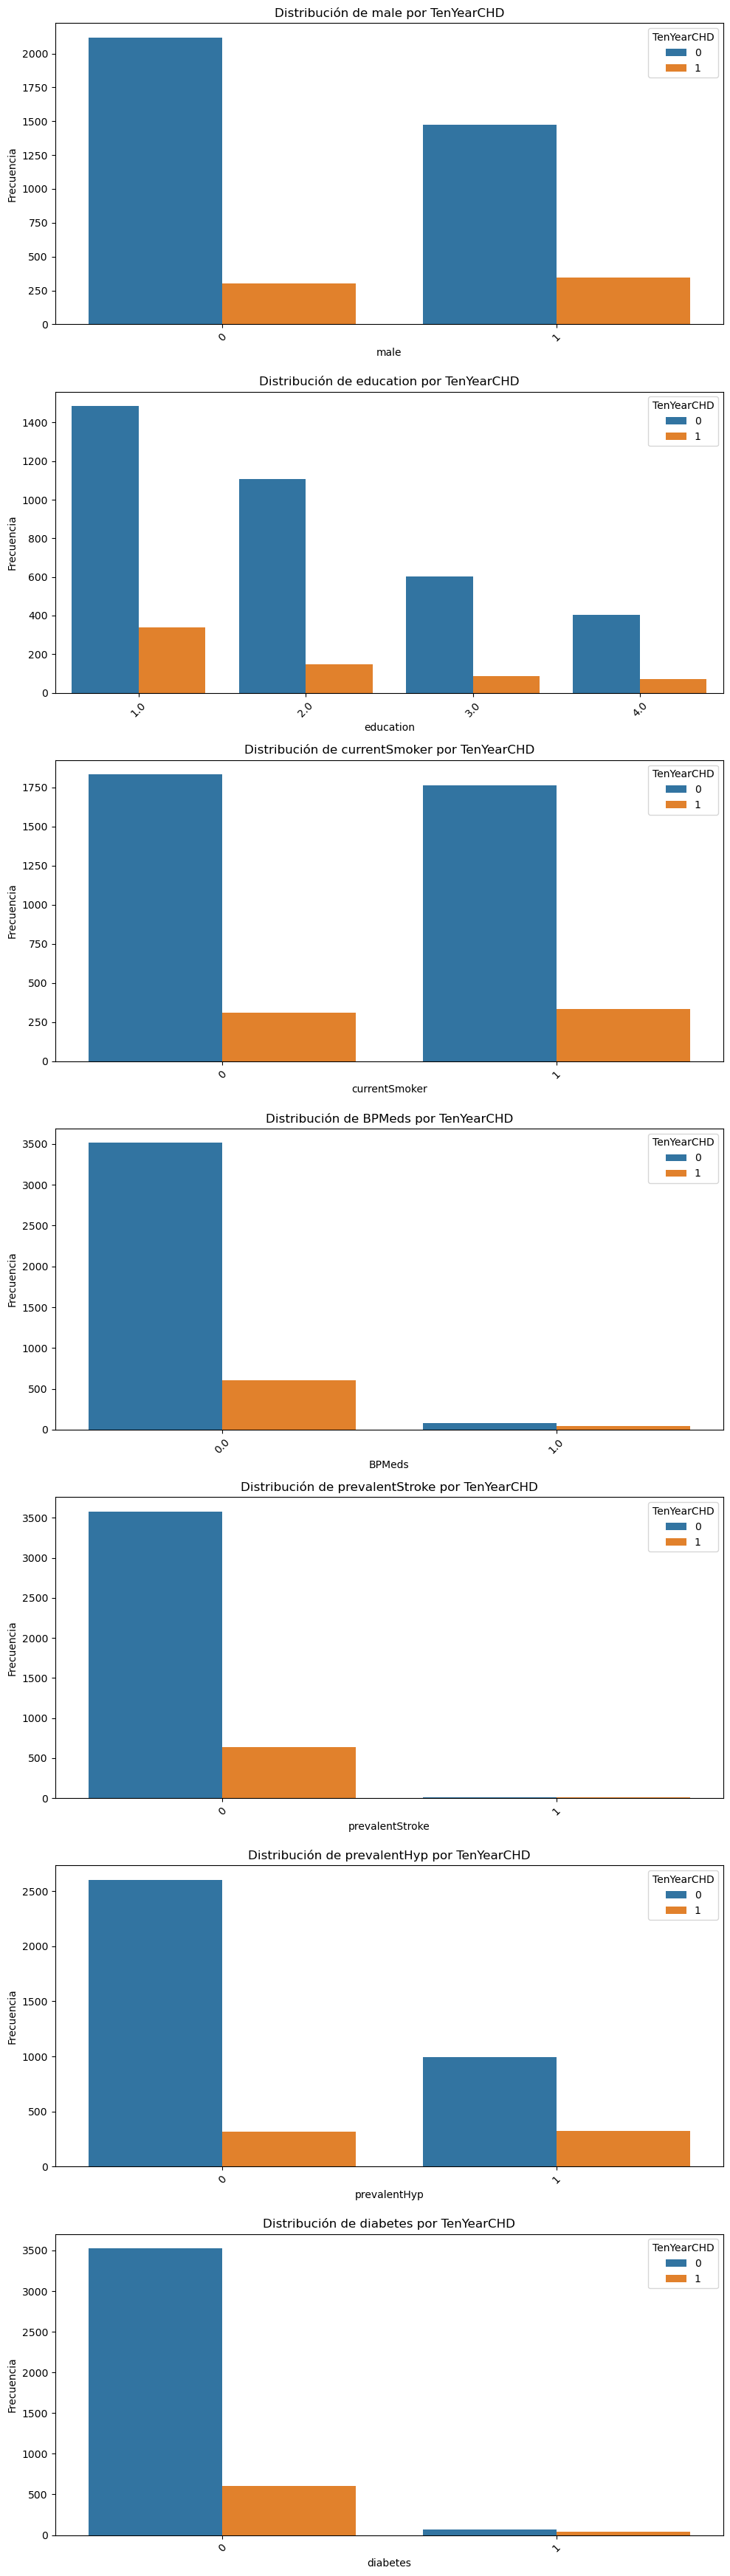

In [ ]:
# en esta primera parte me he ayudado de la ia, pero lo que hace es definir la variable objetivo de lo que quiero analizar si una perosna desarrollará enfermedad coronaria en 10 años.
target = 'TenYearCHD'
#y aqui es lsta de variables categóricas o binarias
str_cols = [
    'male',
    'education',
    'currentSmoker',
    'BPMeds',
    'prevalentStroke',
    'prevalentHyp',
    'diabetes'
]
#a partir de aqui he tomado como ejemplo un EDA del canvas
# Vamos a ver como se distribuyen las variables categoricas con respecto a la variable target
fig, axs = plt.subplots(
    nrows=len(str_cols),
    ncols=1,
    figsize=(10, 5 * len(str_cols))
)

for i, col in enumerate(str_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=target,
        ax=axs[i],
        order=df[col].value_counts().index
    )
    
    axs[i].set_title(f'Distribución de {col} por {target}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor interpretación
    axs[i].legend(title=target)

plt.tight_layout()
plt.show()

Este análisis bivariado sirve para ver cómo influyen las variables categóricas en el riesgo de desarrollar enfermedad coronaria (TenYearCHD). Con gráficos de barras comparo factores como fumar, tener diabetes o hipertensión según si el paciente ha desarrollado la enfermedad o no. Así es más fácil detectar qué características pueden estar más relacionadas con un mayor riesgo cardiovascular.

Correlaciones

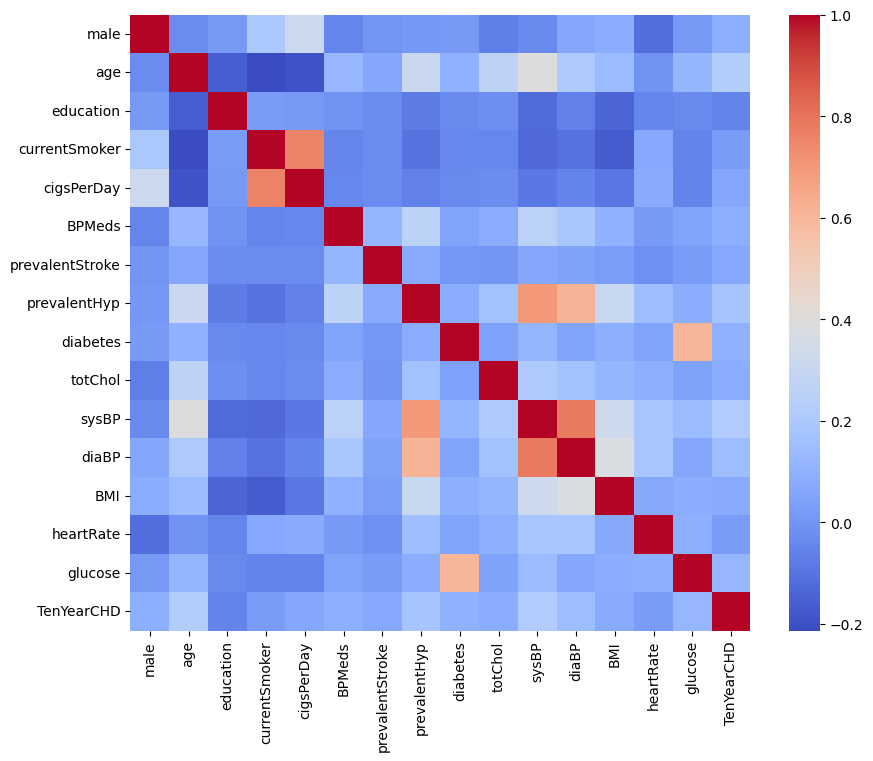

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

Podemos ver  correlaciones positivas entre presión arterial, edad y riesgo cardiovascular.

Ahora vamos a ver si hay estacionalidad en el riesgo de enfermedad coronaria

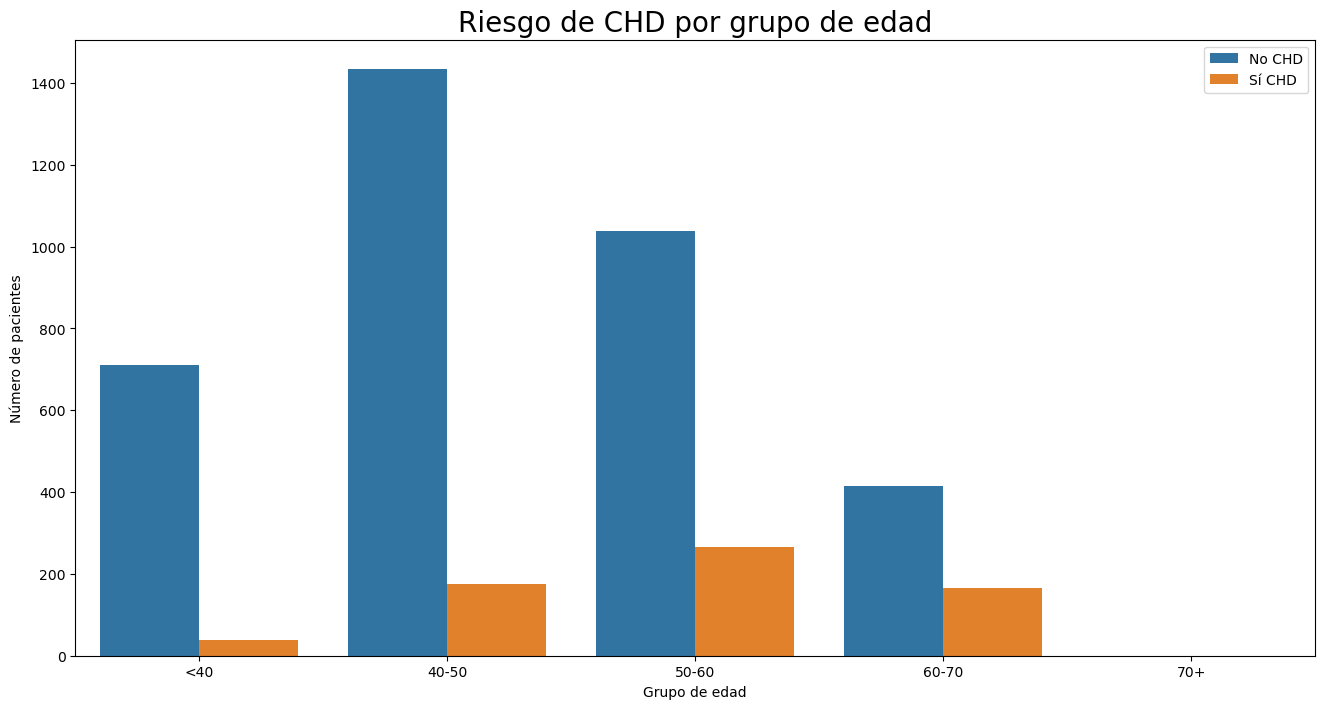

In [30]:


df['age_group'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 70, 100],
                              labels=['<40', '40-50', '50-60', '60-70', '70+'])

plt.figure(figsize=(16,8))

ax1 = sns.countplot(
    x='age_group',
    hue='TenYearCHD',
    data=df
)

legend_labels, _ = ax1.get_legend_handles_labels()

plt.title('Riesgo de CHD por grupo de edad', size=20)
plt.xlabel('Grupo de edad')
plt.ylabel('Número de pacientes')
plt.legend(['No CHD', 'Sí CHD'])
plt.show()

Detecto outliers con iQR me he ayudado de la ia 

In [33]:
def detectar_outliers(df, cols):
    outliers_dict = {}
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers_dict[col] = len(outliers)
    
    return outliers_dict


outliers = detectar_outliers(df, numeric_cols)
print(outliers)

{'age': 0, 'cigsPerDay': 12, 'totChol': 57, 'sysBP': 126, 'diaBP': 77, 'BMI': 97, 'heartRate': 76, 'glucose': 262}


en este dataset no los elimino, mejor winsorizar (capar valores extremos)

In [34]:
def winsorizar(df, cols):
    df_w = df.copy()
    
    for col in cols:
        Q1 = df_w[col].quantile(0.25)
        Q3 = df_w[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df_w[col] = np.where(df_w[col] < lower, lower, df_w[col])
        df_w[col] = np.where(df_w[col] > upper, upper, df_w[col])
    
    return df_w


df_wins = winsorizar(df, numeric_cols)

En este análisis se realizó una limpieza de datos tratando los valores nulos y los valores atípicos.

Los valores nulos se imputaron según el tipo de variable: mediana en variables numéricas, moda en categóricas y 0 en variables binarias.

Para detectar outliers he utilizado el IQR (rango intercuartílico), que es la diferencia entre el tercer y el primer cuartil (Q3 − Q1) y permite identificar valores que se alejan del rango central de los datos.

En lugar de eliminarlos, se aplicó winsorización, limitando los valores extremos, porque pueden representar casos reales de pacientes con alto riesgo cardiovascular.

Análisis multivariante

In [36]:
df_clean = df.copy()

Pairplot de las variables numéricas 

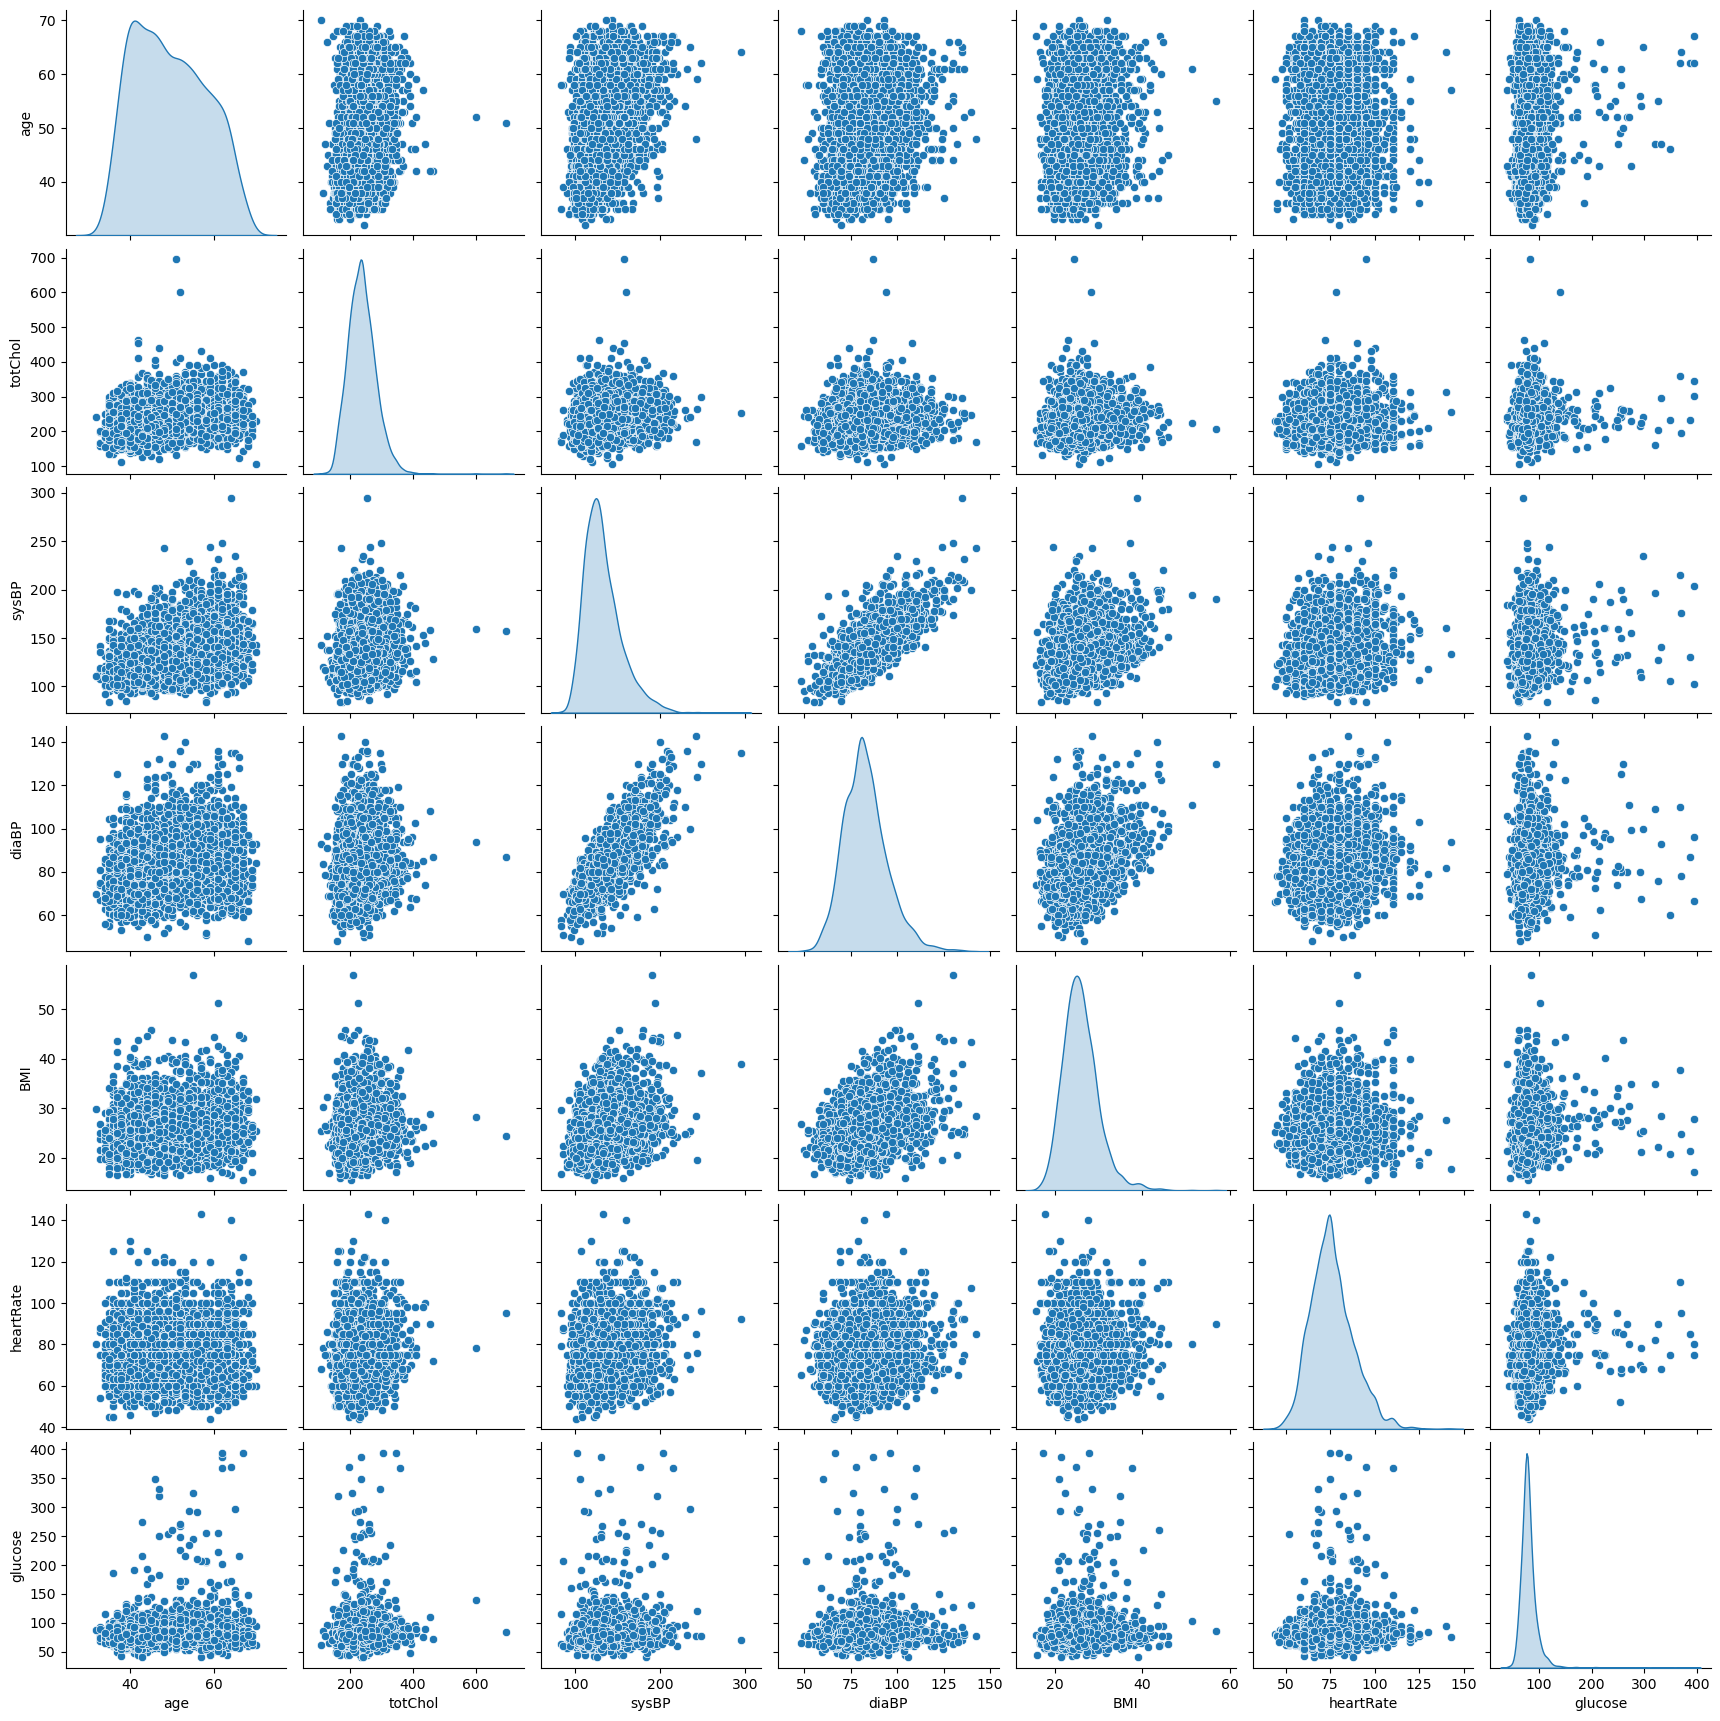

In [37]:
numeric_cols = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

sns.pairplot(df_clean[numeric_cols], diag_kind='kde')
plt.show()

Correlación con la variable objetivo

In [38]:
numeric_cols_with_target = numeric_cols.copy()
numeric_cols_with_target.append('TenYearCHD')

corr = df_clean[numeric_cols_with_target].corr()
corr_target = corr['TenYearCHD'].sort_values(ascending=False)

corr_target

TenYearCHD    1.000000
age           0.225408
sysBP         0.216374
diaBP         0.145112
glucose       0.121319
totChol       0.081749
BMI           0.074326
heartRate     0.022907
Name: TenYearCHD, dtype: float64

Chi-cuadrado ( me he ayudado de la ia ) sirve para ver dos variables categóricas estan relacionadas o no

In [39]:
from scipy.stats import chi2_contingency

def chi_square_test(df, col1, col2):
    contingency_table = pd.crosstab(df[col1], df[col2])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    return chi2, p

def analyze_categorical_relationships(df, categorical_cols):
    results = []
    for i in range(len(categorical_cols)):
        for j in range(i + 1, len(categorical_cols)):
            col1 = categorical_cols[i]
            col2 = categorical_cols[j]
            chi2, p = chi_square_test(df, col1, col2)
            results.append((col1, col2, chi2, p))
    return results

str_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

categorical_relationships = analyze_categorical_relationships(df_clean, str_cols)

results_df = pd.DataFrame(categorical_relationships, columns=['col1', 'col2', 'chi2', 'p-value'])
results_df['significant'] = results_df['p-value'] < 0.05

results_df['p-value'] = results_df['p-value'].apply(lambda x: '{:.2e}'.format(x))
results_df['chi2'] = results_df['chi2'].apply(lambda x: '{:.2f}'.format(x))

results_df.sort_values(by='chi2', ascending=False, inplace=True)
results_df

,col1,col2,chi2,p-value,significant
11,BPMeds,diabetes,9.36,2.22e-03,True
5,currentSmoker,BPMeds,9.35,2.24e-03,True
8,currentSmoker,diabetes,7.77,5.33e-03,True
9,BPMeds,prevalentStroke,47.17,6.52e-12,True
7,currentSmoker,prevalentHyp,45.16,1.82e-11,True
6,currentSmoker,prevalentStroke,3.79,5.15e-02,False
10,BPMeds,prevalentHyp,280.19,6.81e-63,True
14,prevalentHyp,diabetes,24.58,7.12e-07,True
12,prevalentStroke,prevalentHyp,21.65,3.27e-06,True
0,male,currentSmoker,163.80,1.67e-37,True


Cramers'v(ayuda con ia) mide la fuerza de la relacion previa hecha con el chi-cuadrado

In [40]:
def cramers_v(x, y):
    tabla_cruzada = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(tabla_cruzada)
    n = tabla_cruzada.sum().sum()
    min_dim = min(tabla_cruzada.shape) - 1
    
    if min_dim == 0:
        return np.nan
    
    return np.sqrt(chi2 / (n * min_dim))


cramers_v_results = []

for i in range(len(str_cols)):
    for j in range(i + 1, len(str_cols)):
        col1 = str_cols[i]
        col2 = str_cols[j]
        cv = cramers_v(df_clean[col1], df_clean[col2])
        cramers_v_results.append((col1, col2, cv))

cramers_v_df = pd.DataFrame(cramers_v_results, columns=['col1', 'col2', 'Cramér V'])
cramers_v_df['Cramér V'] = cramers_v_df['Cramér V'].apply(lambda x: '{:.2f}'.format(x))

cramers_v_df.sort_values(by='Cramér V', ascending=False, inplace=True)
cramers_v_df.head(20)

,col1,col2,Cramér V
10,BPMeds,prevalentHyp,0.26
0,male,currentSmoker,0.20
9,BPMeds,prevalentStroke,0.11
7,currentSmoker,prevalentHyp,0.10
14,prevalentHyp,diabetes,0.08
12,prevalentStroke,prevalentHyp,0.07
1,male,BPMeds,0.05
5,currentSmoker,BPMeds,0.05
11,BPMeds,diabetes,0.05
8,currentSmoker,diabetes,0.04


Aqui voy a filtrar las variables importantes >0.2 

TenYearCHD    1.000000
age           0.225408
sysBP         0.216374
Name: TenYearCHD, dtype: float64


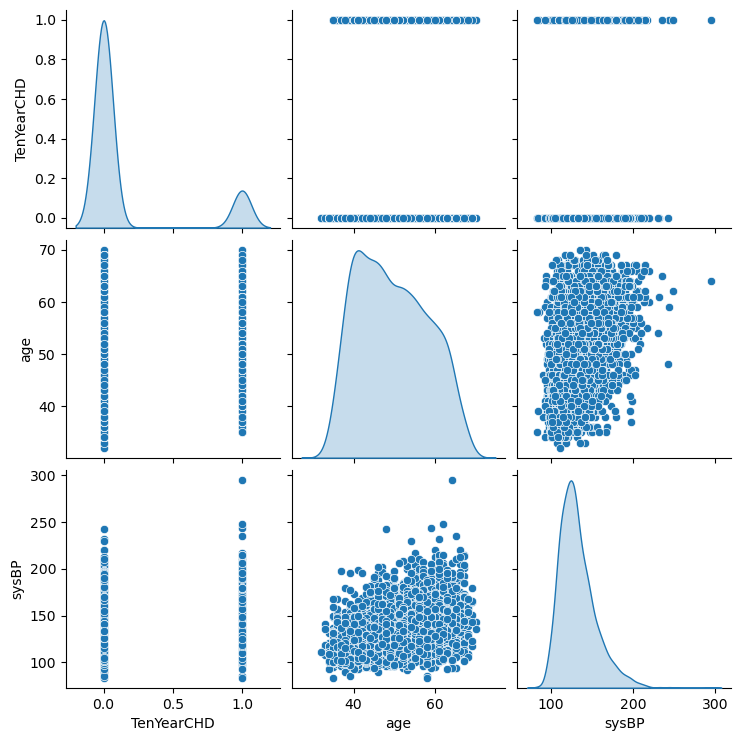

In [41]:
corr_target_selected = corr['TenYearCHD'].sort_values(ascending=False)
corr_target_selected = corr_target_selected[abs(corr_target_selected) > 0.2]

print(corr_target_selected)

numeric_cols_target = corr_target_selected.index.tolist()

sns.pairplot(df_clean[numeric_cols_target], diag_kind='kde')
plt.show()

Anova, lo que hace es mirar si las diferencias de edad entre los grupos son grandes
o si esas diferencias podrían ser solo casualidad

In [42]:
from scipy.stats import f_oneway

group1 = df_clean[df_clean['TenYearCHD'] == 0]['age']
group2 = df_clean[df_clean['TenYearCHD'] == 1]['age']

anova_result = f_oneway(group1, group2)

print('ANOVA test results:')
print(f'F-statistic: {anova_result.statistic}')
print(f'p-value: {anova_result.pvalue}')

ANOVA test results:
F-statistic: 226.8531677977382
p-value: 5.573313255348952e-50


como p-value es < 0,05 si hay una diferencia significativa en la edad entre los grupos

 Conclusiones

 Despues de analizar el datset, se puede ver que son datos bastantes completos sobre factores de salud relacionados con enfermedades del corazón: He visto variables interesnates como la edad, el colesterol, la presión arterial o si la persona fuma, que parecen importantes para el análisis.

 He detectado variables nulos en varias columnas (como glucosa, colesterol, BMI, etc.), pero no eran demasiados en proporción al total. Se pudieron tratar sin mucho problema rellenándolos con valores como la mediana o la moda, dependiendo del tipo de variable. Esto me ha permitido mantener la mayoría de los datos sin tener que eliminar muchas filas.

En el análisis univariante, se observó que muchas variables siguen distribuciones bastante normales, aunque algunas tienen valores extremos (outliers), por ejemplo en colesterol o presión arterial. También se vio que hay bastantes variables binarias (0 y 1), lo que facilita su interpretación.

Por otro lado, en el análisis bivariante se empiezan a ver relaciones interesantes. La mas clara es que la edad influye bastante en el riesgo de enfermedad cardíaca, ya que las personas mayores tienden a tener más probabilidad de desarrollarla. También parece que factores como fumar, la hipertensión o el colesterol alto pueden estar relacionados con un mayor riesgo.

Otra cosa importante es que la variable objetivo (TenYearCHD) está desbalanceada, ya que hay muchas mas personas sin enfermedad que con enfermedad.

En resumen, el dataset es adecuado para hcer modelos de prediccion y el EDA ha servido para entender mejor los datos, limpiar los valores problemáticos y detectar que variables pueden ser más importantes. La edad, la presión arterial, el colesterol y hábitos como fumar parecen ser factores clave en el riesgo de enfermedad cardiáca.

Y alguna de las limitaciones que he apreciado son los valores nulos y que el dataset esta desbalanceado 


